<a href="https://colab.research.google.com/github/fazil-s7/unsupervised_learning/blob/main/Association.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Dataset:
    Age  Spending_Score
0    18              20
1    19              22
2    20              25
3    21              28
4    22              30
5    25              35
6    27              38
7    28              40
8    30              45
9    32              48
10   34              52
11   35              55
12   38              60
13   40              65
14   42              68
15   45              72
16   48              78
17   50              82
18   55              88
19   60              92

===== K-MEANS CLUSTERING =====
    Age  Spending_Score  KMeans_Cluster
0    18              20               1
1    19              22               1
2    20              25               1
3    21              28               1
4    22              30               1
5    25              35               1
6    27              38               1
7    28              40               1
8    30              45               0
9    32              48               0
10   3

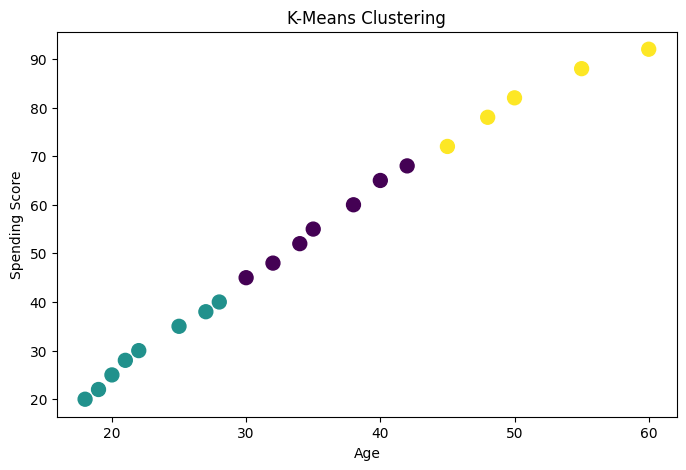

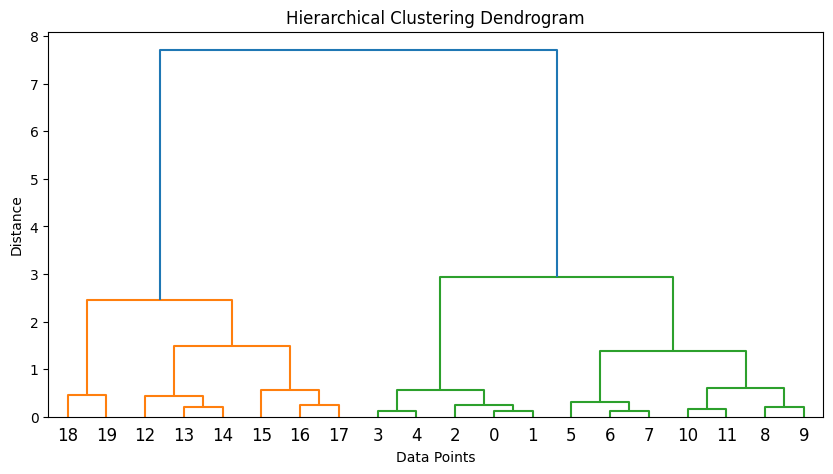


===== HIERARCHICAL CLUSTERING =====
    Age  Spending_Score  Hierarchical_Cluster
0    18              20                     2
1    19              22                     2
2    20              25                     2
3    21              28                     2
4    22              30                     2
5    25              35                     1
6    27              38                     1
7    28              40                     1
8    30              45                     1
9    32              48                     1
10   34              52                     1
11   35              55                     1
12   38              60                     0
13   40              65                     0
14   42              68                     0
15   45              72                     0
16   48              78                     0
17   50              82                     0
18   55              88                     0
19   60              92                    

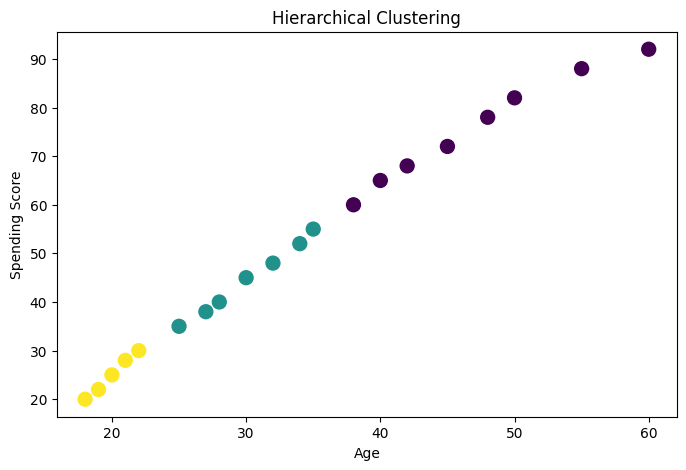


===== DBSCAN CLUSTERING =====
    Age  Spending_Score  DBSCAN_Cluster
0    18              20               0
1    19              22               0
2    20              25               0
3    21              28               0
4    22              30               0
5    25              35               0
6    27              38               0
7    28              40               0
8    30              45               0
9    32              48               0
10   34              52               0
11   35              55               0
12   38              60               0
13   40              65               0
14   42              68               0
15   45              72               0
16   48              78               0
17   50              82               0
18   55              88               0
19   60              92               0


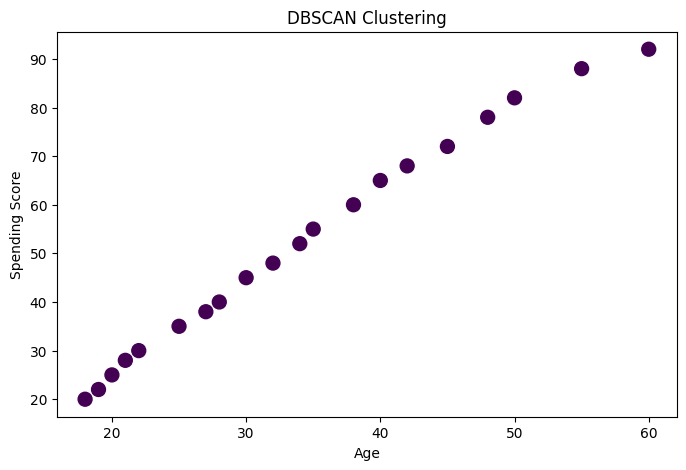


===== FINAL CLUSTERING RESULT =====
    Age  Spending_Score  KMeans_Cluster  Hierarchical_Cluster  DBSCAN_Cluster
0    18              20               1                     2               0
1    19              22               1                     2               0
2    20              25               1                     2               0
3    21              28               1                     2               0
4    22              30               1                     2               0
5    25              35               1                     1               0
6    27              38               1                     1               0
7    28              40               1                     1               0
8    30              45               0                     1               0
9    32              48               0                     1               0
10   34              52               0                     1               0
11   35              55    

In [1]:
# ============================================================
# UNSUPERVISED LEARNING - CLUSTERING
# K-Means + Hierarchical + DBSCAN
# ============================================================

!pip install -q pandas numpy matplotlib scikit-learn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

# ------------------------------------------------------------
# 1. CREATE DATASET
# ------------------------------------------------------------

data = {
    "Age": [18, 19, 20, 21, 22, 25, 27, 28, 30, 32,
            34, 35, 38, 40, 42, 45, 48, 50, 55, 60],

    "Spending_Score": [20, 22, 25, 28, 30, 35, 38, 40, 45, 48,
                       52, 55, 60, 65, 68, 72, 78, 82, 88, 92]
}

df = pd.DataFrame(data)

print("Original Dataset:")
print(df)

# ------------------------------------------------------------
# 2. FEATURE SCALING
# ------------------------------------------------------------

scaler = StandardScaler()
X = scaler.fit_transform(df)

# ============================================================
# 3. K-MEANS CLUSTERING
# ============================================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["KMeans_Cluster"] = kmeans.fit_predict(X)

print("\n===== K-MEANS CLUSTERING =====")
print(df[["Age", "Spending_Score", "KMeans_Cluster"]])

# Visualization
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Age"],
    df["Spending_Score"],
    c=df["KMeans_Cluster"],
    s=100
)

plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("K-Means Clustering")
plt.show()


# ============================================================
# 4. HIERARCHICAL CLUSTERING
# ============================================================

# Create dendrogram
linked = linkage(X, method="ward")

plt.figure(figsize=(10, 5))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

# Apply Agglomerative Clustering
hierarchical = AgglomerativeClustering(
    n_clusters=3
)

df["Hierarchical_Cluster"] = hierarchical.fit_predict(X)

print("\n===== HIERARCHICAL CLUSTERING =====")
print(
    df[
        ["Age", "Spending_Score", "Hierarchical_Cluster"]
    ]
)

# Visualization
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Age"],
    df["Spending_Score"],
    c=df["Hierarchical_Cluster"],
    s=100
)

plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Hierarchical Clustering")
plt.show()


# ============================================================
# 5. DBSCAN CLUSTERING
# ============================================================

dbscan = DBSCAN(
    eps=0.7,
    min_samples=2
)

df["DBSCAN_Cluster"] = dbscan.fit_predict(X)

print("\n===== DBSCAN CLUSTERING =====")
print(
    df[
        ["Age", "Spending_Score", "DBSCAN_Cluster"]
    ]
)

# Visualization
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Age"],
    df["Spending_Score"],
    c=df["DBSCAN_Cluster"],
    s=100
)

plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("DBSCAN Clustering")
plt.show()


# ============================================================
# FINAL RESULT
# ============================================================

print("\n===== FINAL CLUSTERING RESULT =====")

print(df)